## CHECK WHICH ONE IS 0xVF AND 2xVF

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from pathlib import Path
import os
import glob
import scipy.signal as signal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import auc, roc_curve
import scipy.stats
from matplotlib.lines import Line2D

In [2]:
# Path leading to _processedData folders
# data_alingned_path = '/mnt/disk2/Arthur_data/B6J3217-2025-07-02T13-13-14_processedData/aligned_data/B6J3217_downsampled_data_Apply halt: 2s_aligned.csv'
# Define the root path
# work for multiple paths to process
paths_to_process = {
    'processed_data_path_2xVF' : 'C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3',
    'processed_data_path_0xVF' : 'C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day4'
}   

# paths_to_process = {
#     'processed_data_path_0xVF' : '/mnt/disk2/Arthur_data/Visual_mismatch_day3',
#     'processed_data_path_2xVF' : '/mnt/disk2/Arthur_data/Visual_mismatch_day4'
# }  

data_aligned_dict_MM = {key: {} for key in paths_to_process.keys()}

for key, processed_data_path in paths_to_process.items():
    # Find all folders ending with '_processedData'
    processed_folders = glob.glob(os.path.join(processed_data_path, '*_processedData'))
    
    # For each processed folder, look for 'aligned_data' subfolder
    i = 0
    for folder in processed_folders:
        aligned_data_path = os.path.join(folder, 'aligned_data')

        # Check if 'aligned_data' exists and find matching files
        if os.path.exists(aligned_data_path):
            matching_files = glob.glob(os.path.join(aligned_data_path, '*_downsampled_data_Apply halt_2s_aligned.csv'))

            # Print or process the matching files
            for file in matching_files:
                print(f"Found file: {file}")
                # Read the CSV file into a DataFrame
                df = pd.read_csv(file)
                # Store the DataFrame in the dictionary with a dynamic key
                data_aligned_dict_MM[key][f"data_aligned_csv_{i}"] = df
                i += 1

        else:
            print(f"Folder not found: {aligned_data_path}")

# baseline everything cf BASELINE_WINDOWS_SUMMARY
for key in data_aligned_dict_MM.keys():
    for df_key, df in data_aligned_dict_MM[key].items():

        # Creation of new column with index of each MM
        halt_index = 0
        halt_indices = []
        prev_halt_time = None

        for _, row in df.iterrows():
            if row['Halt Time'] != prev_halt_time:
                halt_index += 1
                prev_halt_time = row['Halt Time']
            halt_indices.append(halt_index-1)

        df['halt_index'] = halt_indices

        bin_indices = []

        for _, row in df.iterrows():
            th_time = 10
            for i in range(8):
                if row['Time (s)'] <= th_time:
                    bin_index = 7-i
                    th_time -=2
            
            bin_indices.append(bin_index)

        df['bin_index'] = bin_indices

        # Printing every column names to see every variables
        print(f"Columns in {key} ({df_key}): {df.columns}")


Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2718-2024-12-10T12-57-02_processedData\aligned_data\B6J2718_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2719-2024-12-10T13-36-31_processedData\aligned_data\B6J2719_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2721-2024-12-10T14-18-54_processedData\aligned_data\B6J2721_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2722-2024-12-10T14-58-52_processedData\aligned_data\B6J2722_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2723-2024-12-10T15-36-13_processedData\aligned_data\B6J2723_downsampled_data_Apply halt_2s_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day4\B6J2718-

In [3]:
data_aligned_dict_MM

{'processed_data_path_2xVF': {'data_aligned_csv_0':          Encoder  Position_0X  Position_0Y  CumulativeCounts_0X  \
  0       257.7982       5.3904   -6741.2109             679112.0   
  1       257.7991       5.3904   -6741.2292             679112.0   
  2       257.8000       5.3904   -6741.2477             679114.0   
  3       257.8011       5.3904   -6741.2660             679114.0   
  4       257.8023       5.3904   -6741.2839             679114.0   
  ...          ...          ...          ...                  ...   
  576031  147.2431      78.7268  -31523.2370            9918324.0   
  576032  147.2431      78.7268  -31523.2375            9918324.0   
  576033  147.2431      78.7267  -31523.2379            9918323.0   
  576034  147.2431      78.7267  -31523.2384            9918323.0   
  576035  147.2431      78.7267  -31523.2388            9918323.0   
  
          CumulativeCounts_0Y  dfF_470  dfF_560  dfF_410   z_470   z_560  ...  \
  0                -1482310.0   0.0024

In [4]:
data_aligned_dict_no_MM = {key: {} for key in paths_to_process.keys()}

for key, processed_data_path in paths_to_process.items():
    # Find all folders ending with '_processedData'
    processed_folders = glob.glob(os.path.join(processed_data_path, '*_processedData'))
    
    # For each processed folder, look for 'aligned_data' subfolder
    i = 0
    for folder in processed_folders:
        aligned_data_path = os.path.join(folder, 'aligned_data')

        # Check if 'aligned_data' exists and find matching files
        if os.path.exists(aligned_data_path):
            matching_files = glob.glob(os.path.join(aligned_data_path, '*_downsampled_data_No halt_aligned.csv'))

            # Print or process the matching files
            for file in matching_files:
                print(f"Found file: {file}")
                # Read the CSV file into a DataFrame
                df = pd.read_csv(file)
                # Store the DataFrame in the dictionary with a dynamic key
                data_aligned_dict_no_MM[key][f"data_aligned_csv_{i}"] = df
                i += 1

        else:
            print(f"Folder not found: {aligned_data_path}")

# baseline everything cf BASELINE_WINDOWS_SUMMARY
for key in data_aligned_dict_no_MM.keys():
    for df_key, df in data_aligned_dict_no_MM[key].items():

        # Creation of new column with index of each MM
        halt_index = 0
        halt_indices = []
        prev_halt_time = None

        for _, row in df.iterrows():
            if row['Halt Time'] != prev_halt_time:
                halt_index += 1
                prev_halt_time = row['Halt Time']
            halt_indices.append(halt_index-1)

        df['halt_index'] = halt_indices

        bin_indices = []

        for _, row in df.iterrows():
            th_time = 10
            for i in range(8):
                if row['Time (s)'] <= th_time:
                    bin_index = 7-i
                    th_time -=2
            
            bin_indices.append(bin_index)

        df['bin_index'] = bin_indices

        # Printing every column names to see every variables
        print(f"Columns in {key} ({df_key}): {df.columns}")

Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2718-2024-12-10T12-57-02_processedData\aligned_data\B6J2718_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2719-2024-12-10T13-36-31_processedData\aligned_data\B6J2719_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2721-2024-12-10T14-18-54_processedData\aligned_data\B6J2721_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2722-2024-12-10T14-58-52_processedData\aligned_data\B6J2722_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day3\B6J2723-2024-12-10T15-36-13_processedData\aligned_data\B6J2723_downsampled_data_No halt_aligned.csv
Found file: C:/Users/Arthur/Documents/Master_BIP_CMB/Stage/Data/Cohort1_day4\B6J2718-2024-12-11T13-49-13_processedD

In [5]:
data_aligned_dict_no_MM['processed_data_path_2xVF']['data_aligned_csv_0']['Velocity_0X']

0         -0.0005
1         -0.0005
2         -0.0005
3         -0.0005
4         -0.0005
            ...  
1168068    0.0008
1168069    0.0008
1168070    0.0007
1168071    0.0007
1168072    0.0007
Name: Velocity_0X, Length: 1168073, dtype: float64

## Same thing but with interval -0.5 to 0 / 0 to 1

## Find minimum of -2 to 2 second interval for velocity 0Y and shift all values of velocity 0Y up of this minimum value (so that all values are positive) and then compute delta and ratio as usual

106.8976335


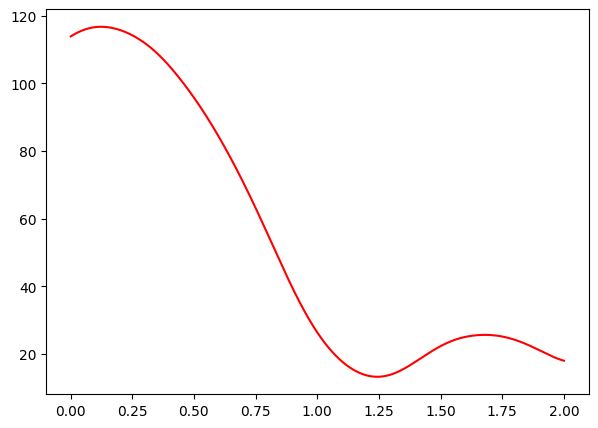

In [6]:
# def shift_velocity_0Y_MM(key, df_key, i):
#     spe_halt_data = data_aligned_dict_MM[key][df_key].loc[data_aligned_dict_MM[key][df_key]['halt_index'] == i]
#     spe_halt_bin_before_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 2]
#     spe_halt_bin_after_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 3]

#     spe_bin_halt_data = pd.concat([spe_halt_bin_before_data, spe_halt_bin_after_data])

#     minimum_value = spe_bin_halt_data['Velocity_0Y'].min()
#     spe_bin_halt_data['Velocity_0Y'] = spe_bin_halt_data['Velocity_0Y'] - minimum_value
#     shifted_before = spe_bin_halt_data.loc[spe_bin_halt_data['bin_index'] == 2]
#     shifted_after = spe_bin_halt_data.loc[spe_bin_halt_data['bin_index'] == 3]

#     return shifted_before, shifted_after

# def shift_velocity_0Y_no_MM(key, df_key, i):
#     spe_halt_data = data_aligned_dict_no_MM[key][df_key].loc[data_aligned_dict_no_MM[key][df_key]['halt_index'] == i]
#     spe_halt_bin_before_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 2]
#     spe_halt_bin_after_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 3]

#     spe_bin_halt_data = pd.concat([spe_halt_bin_before_data, spe_halt_bin_after_data])

#     minimum_value = spe_bin_halt_data['Velocity_0Y'].min()
#     spe_bin_halt_data['Velocity_0Y'] = spe_bin_halt_data['Velocity_0Y'] - minimum_value
#     shifted_before = spe_bin_halt_data.loc[spe_bin_halt_data['bin_index'] == 2]
#     shifted_after = spe_bin_halt_data.loc[spe_bin_halt_data['bin_index'] == 3]

#     return shifted_before, shifted_after

(data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['Velocity_0Y'])
data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['Time (s)']

spe_bin_data1 = data_aligned_dict_MM[key][df_key].loc[data_aligned_dict_MM[key][df_key]['bin_index'] == 2]
spe_bin_data2 = data_aligned_dict_MM[key][df_key].loc[data_aligned_dict_MM[key][df_key]['bin_index'] == 3]

spe_bin_halt_data = spe_bin_data2.loc[spe_bin_data2['halt_index'] == 8]
abs_vel = np.abs(spe_bin_halt_data['Velocity_0Y'])

def compute_auc(ax2, ax1=spe_bin_halt_data['Time (s)']):
    if ax2 is None:
        print('No variable mentionned. Please determine ax2')
        return None
    AUC = auc(ax1, ax2)
    return AUC

AUC = compute_auc(ax2=abs_vel)
print(AUC)

# shifted_before, shifted_after = shift_velocity_0Y_MM(key = 'processed_data_path_0xVF',df_key = 'data_aligned_csv_0', i = 10)
fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(spe_bin_halt_data['Time (s)'], shifted_after['Velocity_0Y'], color = 'red')
ax.plot(spe_bin_halt_data['Time (s)'], abs_vel, color = 'red')
plt.show()

## Getting data for all MM across the session

## Dict for ratio change and delta before after MM

In [126]:
dict_ratios_MM = {key: {} for key in data_aligned_dict_MM.keys()}
dict_delta_MM = {key: {} for key in data_aligned_dict_MM.keys()}

for key in data_aligned_dict_MM.keys():
    print(f"Processing {key}...")
    dict_ratios_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_MM[key].items()}
    dict_delta_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_MM[key].items()}
    
    for df_key, df in data_aligned_dict_MM[key].items():
        print('\n')
        print(f"Processing {df_key}...")

        dict_changes_turning_speed_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_running_speed_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_activ_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_X_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_Y_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_changes_pupil_diam_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_motor_velocity_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}

        dict_turning_speed_delta_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_running_speed_delta_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_activ_delta_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_ellipse_X_delta_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_ellipse_Y_delta_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_pupil_diam_delta_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_motor_velocity_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}
        dict_motor_velocity_delta_MM = {MM: [] for MM in data_aligned_dict_MM[key][df_key]['halt_index']}


        for i in range(np.max(data_aligned_dict_MM[key][df_key]['halt_index'])+1):

            spe_halt_data = data_aligned_dict_MM[key][df_key].loc[data_aligned_dict_MM[key][df_key]['halt_index'] == i]

            spe_halt_bin_before_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 2]
            spe_halt_bin_after_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 3]

            auc_turning_before = auc(spe_halt_bin_before_data['Time (s)'], np.abs(spe_halt_bin_before_data['Velocity_0Y']))
            auc_turning_after = auc(spe_halt_bin_after_data['Time (s)'], np.abs(spe_halt_bin_after_data['Velocity_0Y']))

            mean_running_before = np.mean((spe_halt_bin_before_data['Velocity_0X']))
            mean_running_after = np.mean((spe_halt_bin_after_data['Velocity_0X']))

            mean_activ_before = np.mean((spe_halt_bin_before_data['z_560']))
            mean_activ_after = np.mean((spe_halt_bin_after_data['z_560']))

            auc_motor_before = auc(spe_halt_bin_before_data['Time (s)'], np.abs(spe_halt_bin_before_data['Motor_Velocity']))
            auc_motor_after = auc(spe_halt_bin_after_data['Time (s)'], np.abs(spe_halt_bin_after_data['Motor_Velocity']))

            if 'Ellipse.Center.X_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.X_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_X_before = np.mean((spe_halt_bin_before_data['Ellipse.Center.X_eye1']))
                mean_ellipse_X_after = np.mean((spe_halt_bin_after_data['Ellipse.Center.X_eye1']))
                ratio_ellipse_X__before_after = (mean_ellipse_X_after-mean_ellipse_X_before)/mean_ellipse_X_before
            else:
                print(f"Warning: Missing data for Ellipse.Center.X_eye1 in halt_index {i} of {df_key}. Skipping ratio calculation for this variable.")
                mean_ellipse_X_before = np.nan
                mean_ellipse_X_after = np.nan
                ratio_ellipse_X__before_after = np.nan

            if 'Ellipse.Center.Y_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.Y_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_Y_before = np.mean((spe_halt_bin_before_data['Ellipse.Center.Y_eye1']))
                mean_ellipse_Y_after = np.mean((spe_halt_bin_after_data['Ellipse.Center.Y_eye1']))
                ratio_ellipse_Y_before_after = (mean_ellipse_Y_after-mean_ellipse_Y_before)/mean_ellipse_Y_before
            else:
                print(f"Warning: Missing data for Ellipse.Center.Y_eye1 in halt_index {i} of {df_key}. Skipping ratio calculation for this variable.")
                mean_ellipse_Y_before = np.nan
                mean_ellipse_Y_after = np.nan
                ratio_ellipse_Y_before_after = np.nan

            if 'Pupil.Diameter_eye1' in spe_halt_bin_before_data.columns and 'Pupil.Diameter_eye1' in spe_halt_bin_after_data.columns:
                mean_pupil_diam_before = np.mean((spe_halt_bin_before_data['Pupil.Diameter_eye1']))
                mean_pupil_diam_after = np.mean((spe_halt_bin_after_data['Pupil.Diameter_eye1']))
                ratio_pupil_diam_before_after = (mean_pupil_diam_after-mean_pupil_diam_before)/mean_pupil_diam_before
            else:
                print(f"Warning: Missing data for Pupil.Diameter_eye1 in halt_index {i} of {df_key}. Skipping ratio calculation for this variable.")
                mean_pupil_diam_before = np.nan
                mean_pupil_diam_after = np.nan
                ratio_pupil_diam_before_after = np.nan


            # Ratios
            ratio_turning_before_after = (auc_turning_after-auc_turning_before)/auc_turning_before

            ratio_running_before_after = (mean_running_after-mean_running_before)/mean_running_before

            ratio_activ_before_after = (mean_activ_after-mean_activ_before)/mean_activ_before


            dict_changes_turning_speed_MM[i] = ratio_turning_before_after

            dict_changes_running_speed_MM[i] = ratio_running_before_after

            dict_changes_activ_MM[i] = ratio_activ_before_after

            dict_changes_ellipse_X_MM[i] = ratio_ellipse_X__before_after

            dict_changes_ellipse_Y_MM[i] = ratio_ellipse_Y_before_after

            dict_changes_pupil_diam_MM[i] = ratio_pupil_diam_before_after

            dict_motor_velocity_MM[i] = auc_motor_after


            # Deltas
            dict_turning_speed_delta_MM[i] = auc_turning_after-auc_turning_before

            dict_running_speed_delta_MM[i] = mean_running_after-mean_running_before

            dict_activ_delta_MM[i] = mean_activ_after-mean_activ_before

            dict_ellipse_X_delta_MM[i] = mean_ellipse_X_after-mean_ellipse_X_before

            dict_ellipse_Y_delta_MM[i] = mean_ellipse_Y_after-mean_ellipse_Y_before

            dict_pupil_diam_delta_MM[i] = mean_pupil_diam_after-mean_pupil_diam_before

            dict_motor_velocity_delta_MM[i] = auc_motor_after-auc_motor_before

        table_global_ratio = pd.DataFrame({
            'z_560': list(dict_changes_activ_MM.values()),
            'Velocity_0X': list(dict_changes_running_speed_MM.values()),
            'Velocity_0Y': list(dict_changes_turning_speed_MM.values()),
            'Ellipse.Center.X_eye1': list(dict_changes_ellipse_X_MM.values()),
            'Ellipse.Center.Y_eye1': list(dict_changes_ellipse_Y_MM.values()),
            'Pupil.Diameter_eye1': list(dict_changes_pupil_diam_MM.values()),
            'Motor_Velocity': list(dict_motor_velocity_MM.values())
        })

        dict_ratios_MM[key][df_key] = table_global_ratio

        table_global_delta = pd.DataFrame({
            'z_560': list(dict_activ_delta_MM.values()),
            'Velocity_0X': list(dict_running_speed_delta_MM.values()),
            'Velocity_0Y': list(dict_turning_speed_delta_MM.values()),
            'Ellipse.Center.X_eye1': list(dict_ellipse_X_delta_MM.values()),
            'Ellipse.Center.Y_eye1': list(dict_ellipse_Y_delta_MM.values()),
            'Pupil.Diameter_eye1': list(dict_pupil_diam_delta_MM.values()),
            'Motor_Velocity': list(dict_motor_velocity_MM.values()),
            'Motor_Velocity_delta': list(dict_motor_velocity_delta_MM.values())
        })

        dict_delta_MM[key][df_key] = table_global_delta

dict_ratios_MM
dict_delta_MM

Processing processed_data_path_2xVF...


Processing data_aligned_csv_0...


Processing data_aligned_csv_1...


Processing data_aligned_csv_2...


Processing data_aligned_csv_3...


Processing data_aligned_csv_4...
Processing processed_data_path_0xVF...


Processing data_aligned_csv_0...


Processing data_aligned_csv_1...


Processing data_aligned_csv_2...


Processing data_aligned_csv_3...


Processing data_aligned_csv_4...


{'processed_data_path_2xVF': {'data_aligned_csv_0':        z_560  Velocity_0X  Velocity_0Y  Ellipse.Center.X_eye1  \
  0   2.667626    -0.015662   -72.976300               1.147586   
  1   1.511986     0.087036  -163.961709              -3.747334   
  2   1.813563     0.059069   226.899986              -0.318961   
  3   2.304906     0.011123   -74.690357               5.259880   
  4   1.108432     0.105271   258.623339              -2.841656   
  5   1.067612    -0.039329   -61.734895              -4.173293   
  6   0.795647    -0.000262   -15.505416              -2.759178   
  7   2.655672     0.059610    52.509010              -7.928797   
  8   1.474468     0.059161   -75.251324               2.564917   
  9   0.984639     0.058282   -28.034179              -5.210189   
  10  2.340192     0.099738   153.264698               9.848290   
  11  2.908307     0.129543   142.147022              -5.456311   
  12  2.788348     0.082366   242.867695              -6.944728   
  13  0.9631

## Dict for ratios and delta without MM

In [127]:
dict_ratios_no_MM = {key: {} for key in data_aligned_dict_no_MM.keys()}
dict_delta_no_MM = {key: {} for key in data_aligned_dict_no_MM.keys()}

for key in data_aligned_dict_no_MM.keys():
    print('\n')
    print(f"Processing {key}...")
    dict_ratios_no_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_no_MM[key].items()}
    dict_delta_no_MM[key] = {df_key: [] for df_key, _ in data_aligned_dict_no_MM[key].items()}

    for df_key, df in data_aligned_dict_no_MM[key].items():
        print(f"Processing {df_key}...")

        dict_changes_turning_speed_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_changes_running_speed_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_changes_activ_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_X_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_changes_ellipse_Y_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_changes_pupil_diam_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_motor_velocity_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}

        dict_turning_speed_delta_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_running_speed_delta_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_activ_delta_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_ellipse_X_delta_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_ellipse_Y_delta_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_pupil_diam_delta_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_motor_velocity_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}
        dict_motor_velocity_delta_no_MM = {MM: [] for MM in data_aligned_dict_no_MM[key][df_key]['halt_index']}

        for i in range(np.max(data_aligned_dict_no_MM[key][df_key]['halt_index'])+1):

            spe_halt_data = data_aligned_dict_no_MM[key][df_key].loc[data_aligned_dict_no_MM[key][df_key]['halt_index'] == i]

            spe_halt_bin_before_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 2]
            spe_halt_bin_after_data = spe_halt_data.loc[spe_halt_data['bin_index'] == 3]

            auc_turning_before = auc(spe_halt_bin_before_data['Time (s)'], np.abs(spe_halt_bin_before_data['Velocity_0Y']))
            auc_turning_after = auc(spe_halt_bin_after_data['Time (s)'], np.abs(spe_halt_bin_after_data['Velocity_0Y']))

            mean_running_before = np.mean((spe_halt_bin_before_data['Velocity_0X']))
            mean_running_after = np.mean((spe_halt_bin_after_data['Velocity_0X']))

            mean_activ_before = np.mean(spe_halt_bin_before_data['z_560'])
            mean_activ_after = np.mean(spe_halt_bin_after_data['z_560'])

            auc_motor_before = auc(spe_halt_bin_before_data['Time (s)'], np.abs(spe_halt_bin_before_data['Motor_Velocity']))
            auc_motor_after = auc(spe_halt_bin_after_data['Time (s)'], np.abs(spe_halt_bin_after_data['Motor_Velocity']))

            if 'Ellipse.Center.X_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.X_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_X_before = np.mean((spe_halt_bin_before_data['Ellipse.Center.X_eye1']))
                mean_ellipse_X_after = np.mean((spe_halt_bin_after_data['Ellipse.Center.X_eye1']))
                ratio_ellipse_X__before_after = (mean_ellipse_X_after-mean_ellipse_X_before)/mean_ellipse_X_before
            else:
                print(f"Warning: Missing data for Ellipse.Center.X_eye1 in halt_index {i} of {key}. Skipping ratio calculation for this variable.")
                mean_ellipse_X_before = np.nan
                mean_ellipse_X_after = np.nan
                ratio_ellipse_X__before_after = np.nan

            if 'Ellipse.Center.Y_eye1' in spe_halt_bin_before_data.columns and 'Ellipse.Center.Y_eye1' in spe_halt_bin_after_data.columns:
                mean_ellipse_Y_before = np.mean((spe_halt_bin_before_data['Ellipse.Center.Y_eye1']))
                mean_ellipse_Y_after = np.mean((spe_halt_bin_after_data['Ellipse.Center.Y_eye1']))
                ratio_ellipse_Y_before_after = (mean_ellipse_Y_after-mean_ellipse_Y_before)/mean_ellipse_Y_before
            else:
                print(f"Warning: Missing data for Ellipse.Center.Y_eye1 in halt_index {i} of {key}. Skipping ratio calculation for this variable.")
                mean_ellipse_Y_before = np.nan
                mean_ellipse_Y_after = np.nan
                ratio_ellipse_Y_before_after = np.nan

            if 'Pupil.Diameter_eye1' in spe_halt_bin_before_data.columns and 'Pupil.Diameter_eye1' in spe_halt_bin_after_data.columns:
                mean_pupil_diam_before = np.mean((spe_halt_bin_before_data['Pupil.Diameter_eye1']))
                mean_pupil_diam_after = np.mean((spe_halt_bin_after_data['Pupil.Diameter_eye1']))
                ratio_pupil_diam_before_after = (mean_pupil_diam_after-mean_pupil_diam_before)/mean_pupil_diam_before
            else:
                print(f"Warning: Missing data for Pupil.Diameter_eye1 in halt_index {i} of {key}. Skipping ratio calculation for this variable.")
                mean_pupil_diam_before = np.nan
                mean_pupil_diam_after = np.nan
                ratio_pupil_diam_before_after = np.nan

            # Ratios
            ratio_turning_before_after = (auc_turning_after-auc_turning_before)/auc_turning_before

            ratio_running_before_after = (mean_running_after-mean_running_before)/mean_running_before

            ratio_activ_before_after = (mean_activ_after-mean_activ_before)/mean_activ_before


            dict_changes_turning_speed_no_MM[i] = ratio_turning_before_after

            dict_changes_running_speed_no_MM[i] = ratio_running_before_after

            dict_changes_activ_no_MM[i] = ratio_activ_before_after

            dict_changes_ellipse_X_no_MM[i] = ratio_ellipse_X__before_after

            dict_changes_ellipse_Y_no_MM[i] = ratio_ellipse_Y_before_after

            dict_changes_pupil_diam_no_MM[i] = ratio_pupil_diam_before_after

            dict_motor_velocity_no_MM[i] = auc_motor_after


            # Deltas
            dict_turning_speed_delta_no_MM[i] = auc_turning_after-auc_turning_before

            dict_running_speed_delta_no_MM[i] = mean_running_after-mean_running_before

            dict_activ_delta_no_MM[i] = mean_activ_after-mean_activ_before

            dict_ellipse_X_delta_no_MM[i] = mean_ellipse_X_after-mean_ellipse_X_before

            dict_ellipse_Y_delta_no_MM[i] = mean_ellipse_Y_after-mean_ellipse_Y_before

            dict_pupil_diam_delta_no_MM[i] = mean_pupil_diam_after-mean_pupil_diam_before

            dict_motor_velocity_delta_no_MM[i] = auc_motor_after-auc_motor_before

        table_global_ratio = pd.DataFrame({
            'z_560': list(dict_changes_activ_no_MM.values()),
            'Velocity_0X': list(dict_changes_running_speed_no_MM.values()),
            'Velocity_0Y': list(dict_changes_turning_speed_no_MM.values()),
            'Ellipse.Center.X_eye1': list(dict_changes_ellipse_X_no_MM.values()),
            'Ellipse.Center.Y_eye1': list(dict_changes_ellipse_Y_no_MM.values()),
            'Pupil.Diameter_eye1': list(dict_changes_pupil_diam_no_MM.values()),
            'Motor_Velocity': list(dict_motor_velocity_no_MM.values())
        })

        dict_ratios_no_MM[key][df_key] = table_global_ratio



        table_global_delta = pd.DataFrame({
            'z_560': list(dict_activ_delta_no_MM.values()),
            'Velocity_0X': list(dict_running_speed_delta_no_MM.values()),
            'Velocity_0Y': list(dict_turning_speed_delta_no_MM.values()),
            'Ellipse.Center.X_eye1': list(dict_ellipse_X_delta_no_MM.values()),
            'Ellipse.Center.Y_eye1': list(dict_ellipse_Y_delta_no_MM.values()),
            'Pupil.Diameter_eye1': list(dict_pupil_diam_delta_no_MM.values()),
            'Motor_Velocity': list(dict_motor_velocity_no_MM.values()),
            'Motor_Velocity_delta': list(dict_motor_velocity_delta_no_MM.values())
        })
            
        dict_delta_no_MM[key][df_key] = table_global_delta

dict_ratios_no_MM



Processing processed_data_path_2xVF...
Processing data_aligned_csv_0...
Processing data_aligned_csv_1...
Processing data_aligned_csv_2...
Processing data_aligned_csv_3...
Processing data_aligned_csv_4...


Processing processed_data_path_0xVF...
Processing data_aligned_csv_0...
Processing data_aligned_csv_1...
Processing data_aligned_csv_2...
Processing data_aligned_csv_3...
Processing data_aligned_csv_4...


{'processed_data_path_2xVF': {'data_aligned_csv_0':        z_560  Velocity_0X  Velocity_0Y  Ellipse.Center.X_eye1  \
  0  -0.672423     0.565447    -0.563683              -1.007083   
  1  -0.453504     0.172311     0.320779               0.714978   
  2  -2.525018    -0.037753    -0.117053              -1.438775   
  3  -0.786817    -0.352076    -0.645002              -4.007183   
  4   4.735218     1.435542     0.611843               1.783892   
  ..       ...          ...          ...                    ...   
  68 -1.199397     0.305417    -0.141559              -0.766271   
  69  0.757464     2.997032     0.406168             -31.163433   
  70  0.261421    -0.212820    -0.096903              -0.702145   
  71  0.661253     9.613758     2.549927             -31.161878   
  72 -0.393697     0.822646    -0.001104              -0.507595   
  
      Ellipse.Center.Y_eye1  Pupil.Diameter_eye1  Motor_Velocity  
  0               -0.124662             0.072003       12.407332  
  1      

In [9]:
mouse = 'data_aligned_csv_0'
param_to_analyse = 'Motor_Velocity'
# for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
#     print(i)

dict_ratios_MM['processed_data_path_0xVF'][mouse]['Motor_Velocity'].values

# values_noMM = []
# for i in range(len(dict_ratios_no_MM['processed_data_path_0xVF'][mouse])):
#     values_noMM.append(dict_ratios_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
# for i in range(len(dict_ratios_no_MM['processed_data_path_2xVF'][mouse])):
#     values_noMM.append(dict_ratios_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

array([28.1600978 , 29.38890135, 23.3641061 , 19.87920755, 28.13697295,
       33.268038  , 20.80629975, 29.7378643 , 26.26309615, 33.26454895,
        6.8221579 , 16.54647735,  2.7787108 , 11.6709839 , 21.73248205,
       18.4754683 ,  7.02726815,  8.02006855, 11.1605273 , 27.7142921 ,
       18.56777595, 26.995056  , 43.99236075, 19.1780904 , 15.1517981 ,
       13.02651365,  9.95214085, 20.3570358 , 24.74402625, 12.4598372 ,
        9.28210385,  6.05610235, 13.448004  , 32.333621  , 18.87253135,
       20.63096835,  8.9836538 ,  3.4439223 , 28.11773055, 31.351739  ,
       19.39162535, 13.04360415, 18.2833005 ])

(0.5, 0)


C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\1762791893.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])


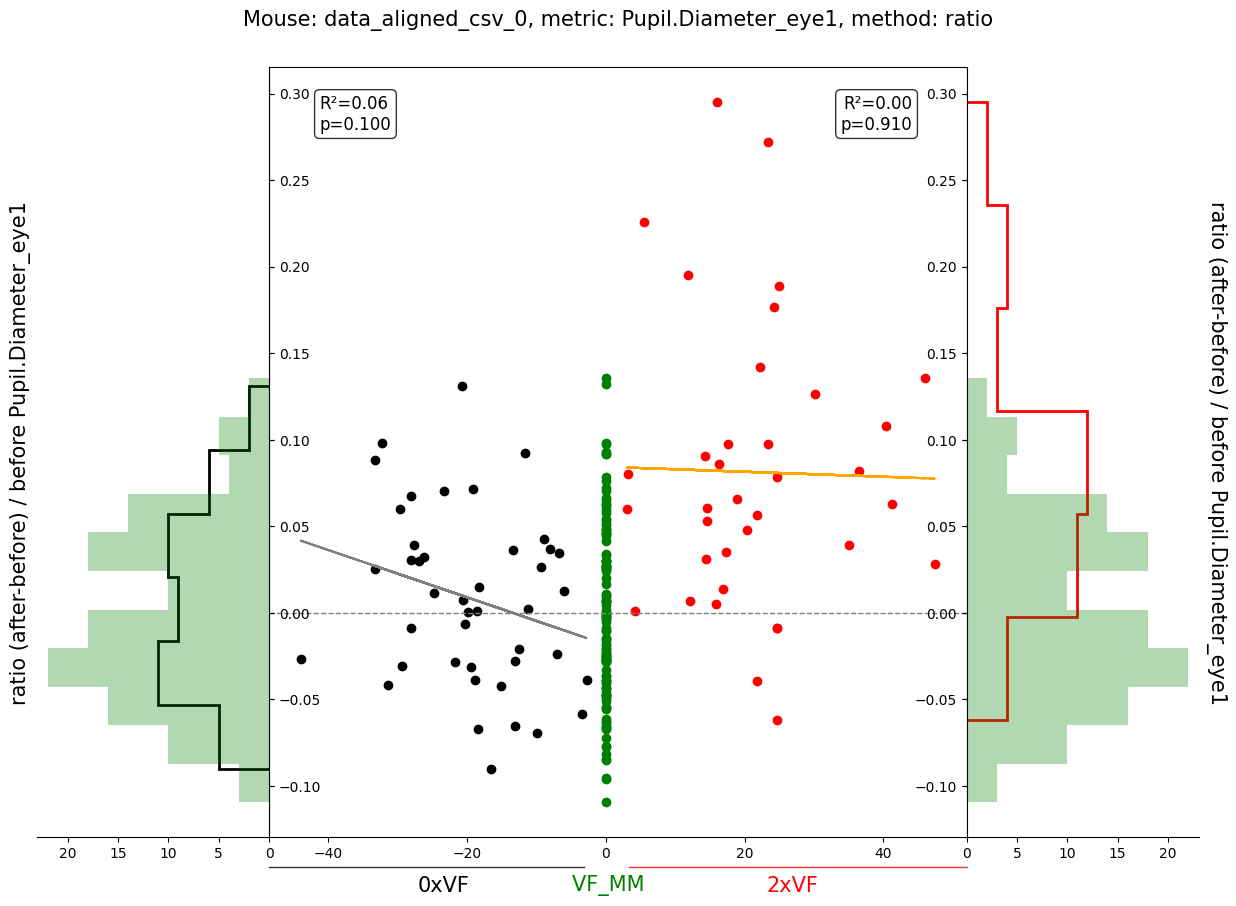

In [ ]:
# B6J2718 : 
# PC office 
# processed_data_path_2xVF : data_aligned_csv_4
# processed_data_path_0xVF : data_aligned_csv_3

# PC Arthur
# processed_data_path_2xVF : data_aligned_csv_0
# processed_data_path_0xVF : data_aligned_csv_0

def fig_1(param_to_analyse, mouse, method):
    values_2VF, values_noMM, values_0VF = [], [], []
    values_motor_2VF, values_motor_0VF, values_motor_noMM = [], [], []

    if method.casefold() == 'ratio':
        for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
            values_2VF.append(dict_ratios_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_ratios_MM['processed_data_path_0xVF'][mouse])):
            values_0VF.append(dict_ratios_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_ratios_no_MM['processed_data_path_0xVF'][mouse])):
            values_noMM.append(dict_ratios_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        for i in range(len(dict_ratios_no_MM['processed_data_path_2xVF'][mouse])):
            values_noMM.append(dict_ratios_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

    elif method.casefold() == 'delta':
        for i in range(len(dict_delta_MM['processed_data_path_2xVF'][mouse])):
            values_2VF.append(dict_delta_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_delta_MM['processed_data_path_0xVF'][mouse])):
            values_0VF.append(dict_delta_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_delta_no_MM['processed_data_path_0xVF'][mouse])):
            values_noMM.append(dict_delta_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        for i in range(len(dict_delta_no_MM['processed_data_path_2xVF'][mouse])):
            values_noMM.append(dict_delta_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

    else :
        print('Method must be "ratio" or "delta".')
        return
        
    for i in range(len(dict_ratios_MM['processed_data_path_0xVF'][mouse])):
        values_motor_0VF.append(-1*(dict_ratios_MM['processed_data_path_0xVF'][mouse]['Motor_Velocity'][i]))
    for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
        values_motor_2VF.append(dict_ratios_MM['processed_data_path_2xVF'][mouse]['Motor_Velocity'][i])
    for _ in range(len(values_noMM)):
        values_motor_noMM.append(0)


    fig, (ax_left, ax_main, ax_right) = plt.subplots(1, 3,figsize=(15, 10), sharey=True, width_ratios=[1,3,1])
    fig.subplots_adjust(wspace=0)

    # Points
    ax_main.plot(values_motor_0VF, values_0VF, marker='o', color = 'black', linestyle='None')
    m0, b0, r_value0, p_value0, std_err0 = scipy.stats.linregress(values_motor_0VF, values_0VF)
    ax_main.plot(values_motor_0VF, m0*np.array(values_motor_0VF) + b0, color = 'gray')

    ax_main.plot(values_motor_2VF, values_2VF, marker='o', color = 'red', linestyle='None')
    m2, b2, r_value2, p_value2, std_err2 = scipy.stats.linregress(values_motor_2VF, values_2VF)
    ax_main.plot(values_motor_2VF, m2*np.array(values_motor_2VF) + b2, color = 'orange')

    ax_main.plot(values_motor_noMM, values_noMM, marker='o', color = 'green', linestyle='None')
    ax_main.set_title(f'Mouse: {mouse}, metric: {param_to_analyse}, method: {method}', size=15, pad = 30)

    ax_main.tick_params(axis='y', which='both', direction='in', left=True, right=True, labelleft=False, labelright=False)
    
    x_lim = ax_main.get_xlim()
    y_lim = ax_main.get_ylim()

    ax_main.set_xlabel('VF_MM   ', color = 'green', size=15, labelpad=10)
    xlbl = ax_main.xaxis.get_label()
    xlbl_pos = xlbl.get_position()

    ax_main.text(x_lim[0]*0.85, y_lim[1]*0.95, f'R²={r_value0**2:.2f}\np={p_value0:.3f}', fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax_main.text(x_lim[1]*0.85, y_lim[1]*0.95, f'R²={r_value2**2:.2f}\np={p_value2:.3f}', fontsize=12, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax_main.text(0.25, -0.05, '0xVF', color = 'black', size=15, transform=ax_main.transAxes, ha='center', va='top')
    ax_main.text(0.75, -0.05, '2xVF', color = 'red', size=15, transform=ax_main.transAxes, ha='center', va='top')

    ax_main.axhline(0, color='gray', linestyle='--', linewidth=1)
    line0 = Line2D([0.28, 0.49], [0.08, 0.08], transform=fig.transFigure, color='black', linewidth=1, alpha=0.8)
    fig.add_artist(line0)
    line2 = Line2D([0.52, 0.745], [0.08, 0.08], transform=fig.transFigure, color='red', linewidth=1, alpha=0.8)
    fig.add_artist(line2)

    def calculate_bins(values):
        # q1 = np.percentile(values, 25)
        # q3 = np.percentile(values, 75)
        # iqr = q3 - q1
        # bins = int((max(values) - min(values)) / (2 * iqr / (len(values) ** (1/3))))
        bins = int(np.sqrt(len(values)))
        # print(f"Calculated number of bins: {bins}")
        return bins

    # Histo
    counts_0VF, bins_0VF = np.histogram(values_0VF, bins = calculate_bins(values_0VF))
    counts_2VF, bins_2VF = np.histogram(values_2VF, bins = calculate_bins(values_2VF))
    counts_noMM, bins_noMM = np.histogram(values_noMM, bins = calculate_bins(values_noMM))

    ax_left.stairs(-counts_0VF, bins_0VF, orientation = 'horizontal', color='black', linewidth=2)
    ax_left.stairs(-counts_noMM, bins_noMM, orientation = 'horizontal', color='green', fill=True, alpha=0.3)
    ax_left.tick_params(axis='y', which='both', direction='out', left=False, right=True, labelleft=False, labelright=True)
    xticks = ax_left.get_xticks()
    ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
    # ax_left.tick_params(top=True, labeltop = True, bottom = False, labelbottom = False)
    ax_left.spines['top'].set_visible(False)
    ax_left.spines['left'].set_visible(False)
    ax_left.set_zorder(20)

    ax_right.stairs(counts_2VF, bins_2VF, orientation = 'horizontal', color='red', linewidth=2)
    ax_right.stairs(counts_noMM, bins_noMM, orientation = 'horizontal', color='green', fill=True, alpha=0.3)
    ax_right.tick_params(axis='y', which='both', direction='out', left=True, right=False, labelleft=True, labelright=False)
    # ax_right.tick_params(top=True, labeltop = True, bottom = False, labelbottom = False)
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    ax_right.set_zorder(20)

    if method.casefold() == 'delta':
        ax_left.set_ylabel(f'{method} after-before {param_to_analyse}', size=15)
        ax_right.set_ylabel(f'{method} after-before {param_to_analyse}', size=15, rotation = -90, labelpad = 20)
        ax_right.yaxis.set_label_position('right')
    elif method.casefold() == 'ratio':
        ax_left.set_ylabel(f'{method} (after-before) / before {param_to_analyse}', size=15)
        ax_right.set_ylabel(f'{method} (after-before) / before {param_to_analyse}', size=15, rotation = -90, labelpad = 20)
        ax_right.yaxis.set_label_position('right')
    plt.show()

fig_1(param_to_analyse = 'Pupil.Diameter_eye1', mouse = 'data_aligned_csv_0', method = 'ratio')


0


(-1000.0, 1000.0)

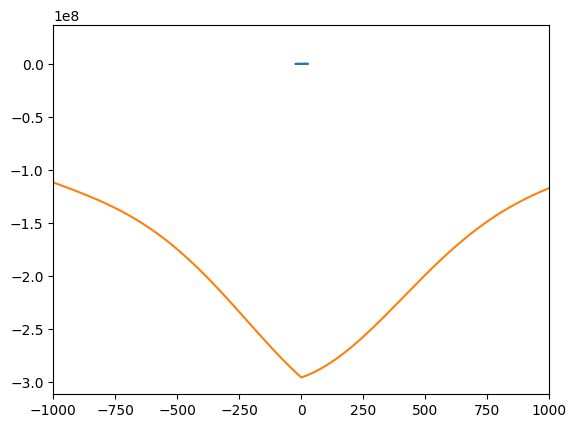

In [12]:
plt.plot(data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['Motor_Velocity'], data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['Velocity_0Y'])
in1 = data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['Motor_Velocity']
in2 = data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['Velocity_0Y']


spe_bin_data1 = data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0'].loc[data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['bin_index'] == 2]
spe_bin_data2 = data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0'].loc[data_aligned_dict_MM['processed_data_path_0xVF']['data_aligned_csv_0']['bin_index'] == 3]
spe_bin_data = pd.concat([spe_bin_data1, spe_bin_data2])
in1 = spe_bin_data['Motor_Velocity']
in2 = spe_bin_data['Velocity_0Y']

corr = signal.correlate(in1, in2, mode='full')
lags = signal.correlation_lags(len(in1), len(in2), mode='full')
lag_at_min_corr = lags[np.argmin(corr)]
print(lag_at_min_corr)
plt.plot(lags, corr)
plt.xlim(-1000, 1000)
# fig, ax = plt.subplots()
# ax.plot(corr)
# ax.set_xlim(0, len(corr))
# ax.set_ylim(-max(corr)*1.1, max(corr)*1.1)

C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{a

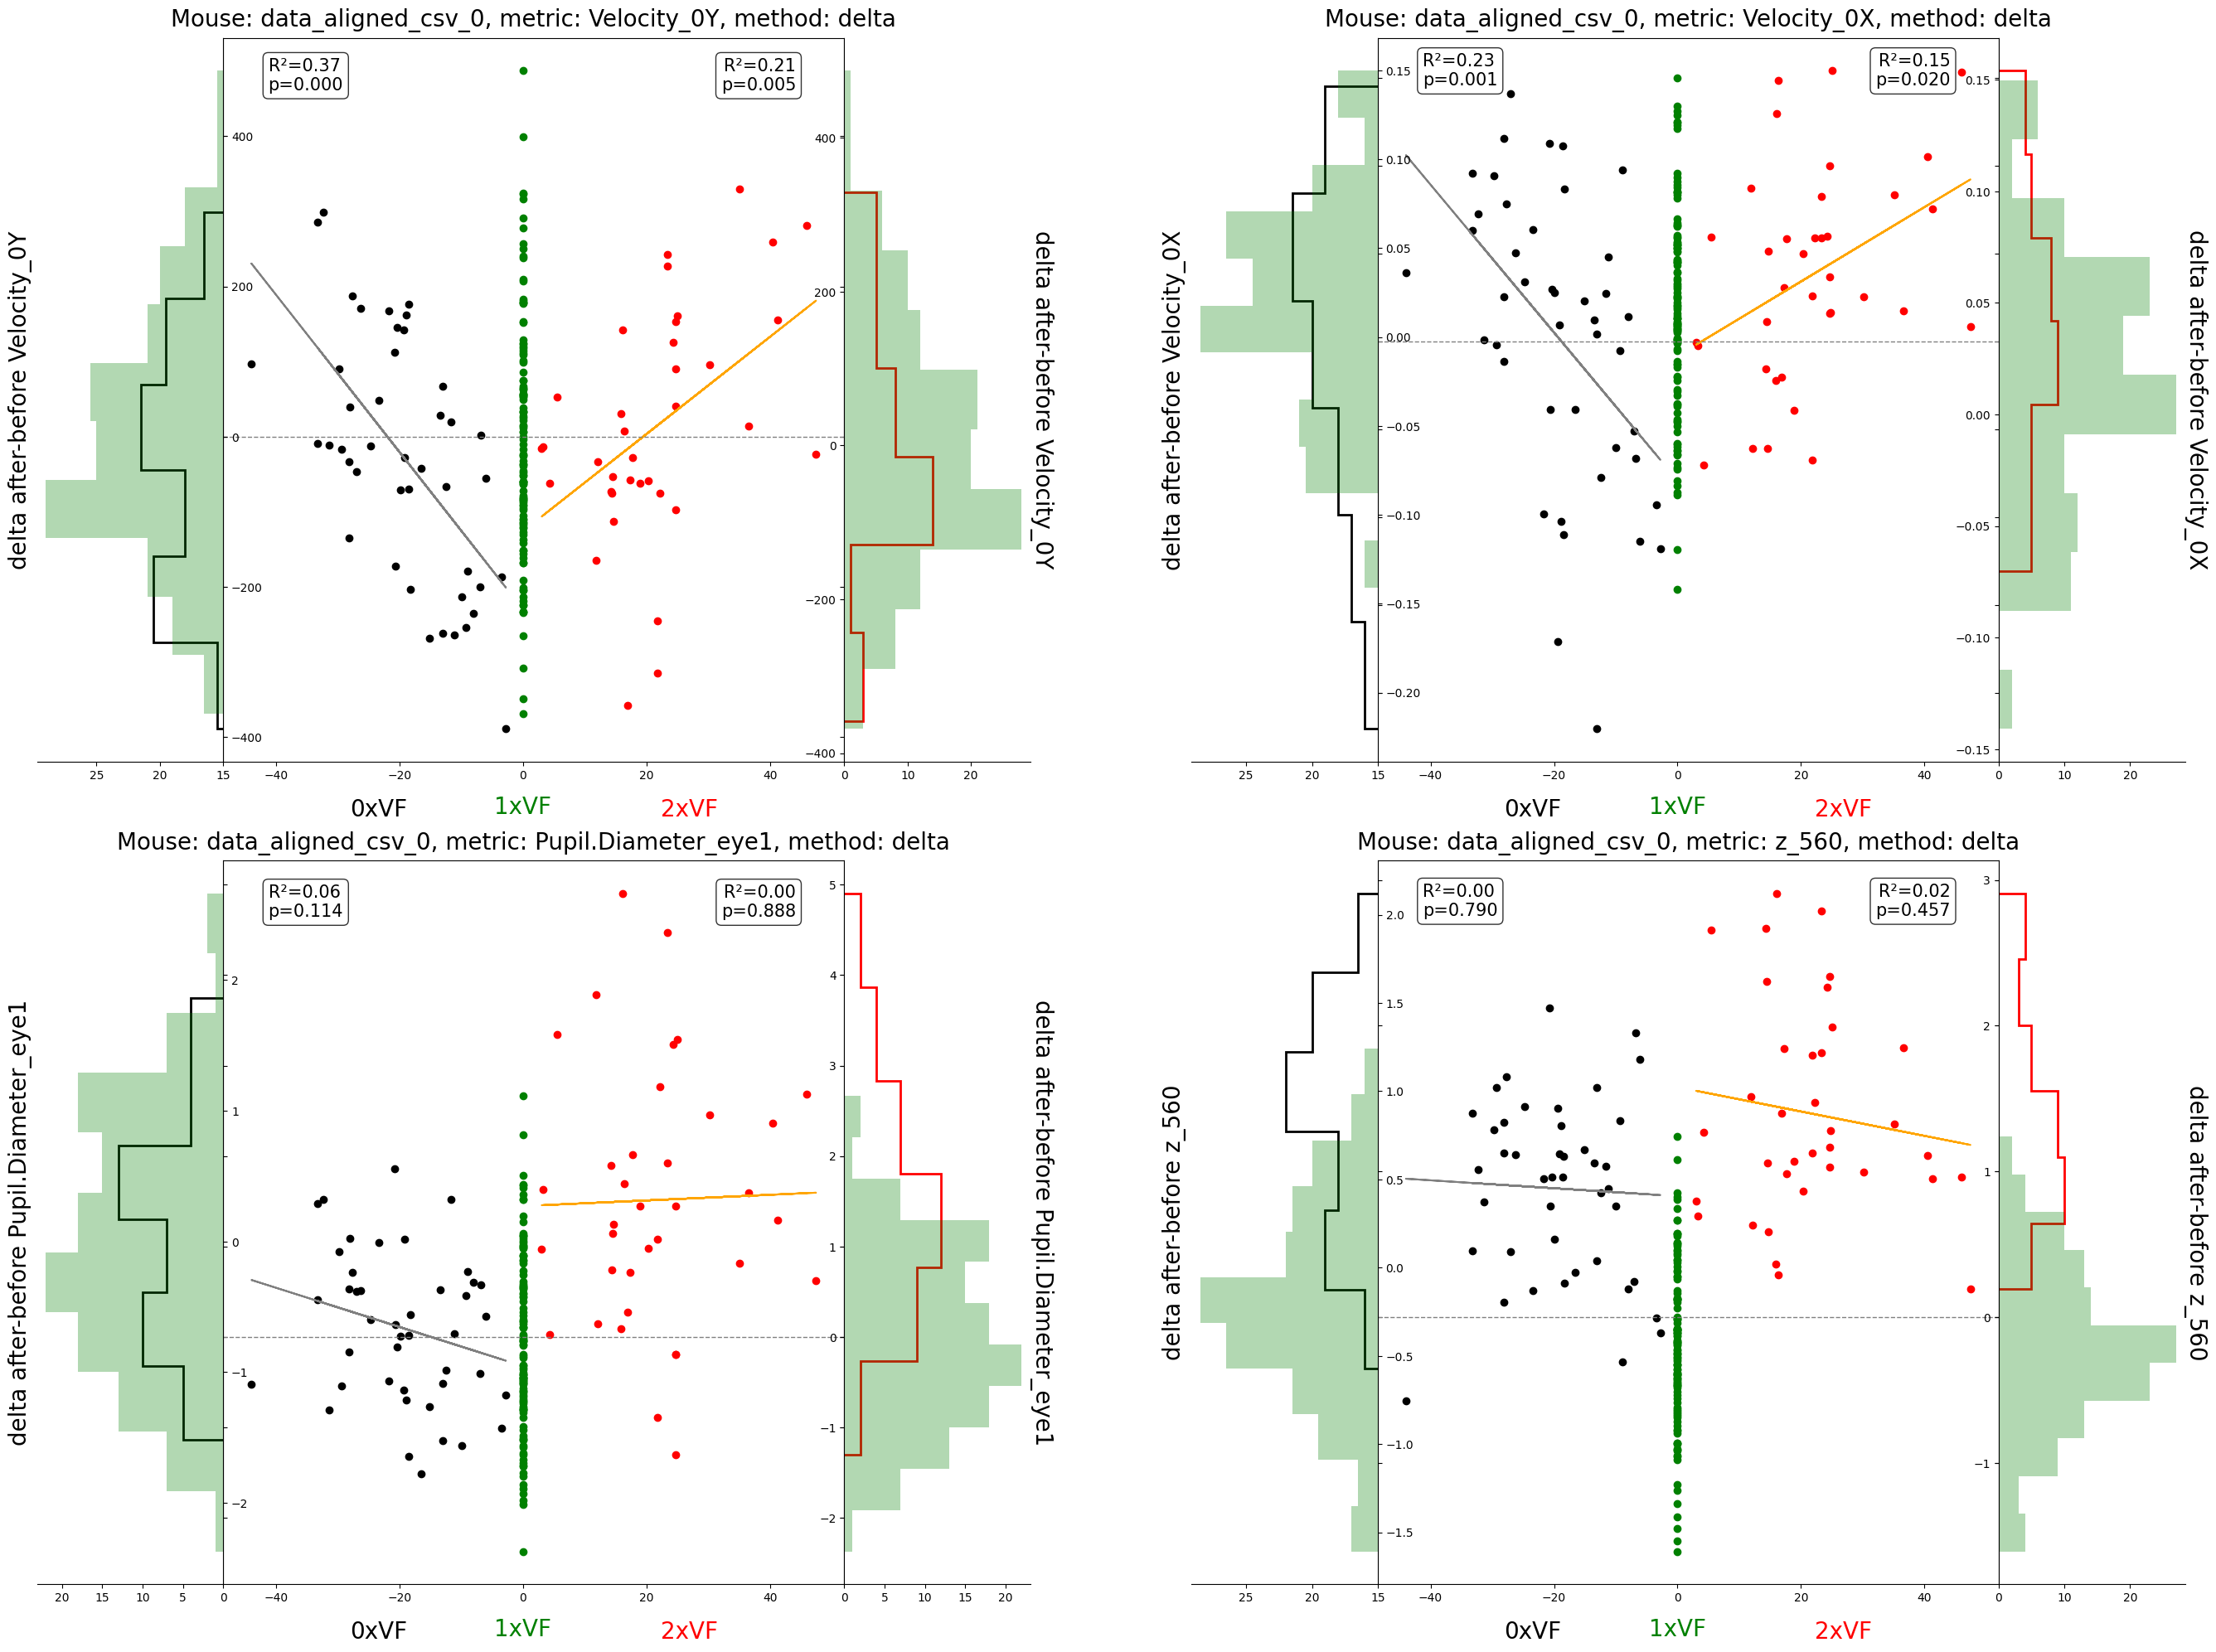

In [139]:
import matplotlib.pyplot as plt

def fig_1_grid(params_to_analyse, mouse, method):
    # Fig with 4 subplots (2 rows, 2 columns)
    fig, axes = plt.subplots(2, 2, figsize=(28, 20))
    fig.subplots_adjust(wspace=0.3, hspace=0.3)

    # Flatten the axes array for easier indexing
    axes = axes.flatten()

    for idx, param in enumerate(params_to_analyse):
        if idx >= 4:
            break  # limit to 4 parameters for the 2x2 grid

        # Call the modified fig_1 function with the current parameter and the corresponding axis
        fig_1(param_to_analyse=param, mouse=mouse, method=method, ax=axes[idx])

    plt.tight_layout()
    plt.show()

# Modified fig_1 function to accept an optional axis parameter
def fig_1(param_to_analyse, mouse, method, ax=None):
    if ax is None:
        fig, (ax_left, ax_main, ax_right) = plt.subplots(1, 3, figsize=(15, 10), sharey=True, width_ratios=[1, 3, 1])
        fig.subplots_adjust(wspace=0)
    else:
        # If an axis is provided, we will create inset axes for the histograms
        ax_main = ax
        ax_left = ax_main.inset_axes([-0.3, 0, 0.3, 1])
        ax_right = ax_main.inset_axes([1.0, 0, 0.3, 1])

    # Get the values for the specified parameter, mouse, and method
    values_2VF, values_noMM, values_0VF = [], [], []
    values_motor_2VF, values_motor_0VF, values_motor_noMM = [], [], []

    if method.casefold() == 'ratio':
        for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
            values_2VF.append(dict_ratios_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_ratios_MM['processed_data_path_0xVF'][mouse])):
            values_0VF.append(dict_ratios_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_ratios_no_MM['processed_data_path_0xVF'][mouse])):
            values_noMM.append(dict_ratios_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        for i in range(len(dict_ratios_no_MM['processed_data_path_2xVF'][mouse])):
            values_noMM.append(dict_ratios_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

    elif method.casefold() == 'delta':
        for i in range(len(dict_delta_MM['processed_data_path_2xVF'][mouse])):
            values_2VF.append(dict_delta_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_delta_MM['processed_data_path_0xVF'][mouse])):
            values_0VF.append(dict_delta_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        
        for i in range(len(dict_delta_no_MM['processed_data_path_0xVF'][mouse])):
            values_noMM.append(dict_delta_no_MM['processed_data_path_0xVF'][mouse][param_to_analyse][i])
        for i in range(len(dict_delta_no_MM['processed_data_path_2xVF'][mouse])):
            values_noMM.append(dict_delta_no_MM['processed_data_path_2xVF'][mouse][param_to_analyse][i])

    else :
        print('Method must be "ratio" or "delta".')
        return
        
    for i in range(len(dict_ratios_MM['processed_data_path_0xVF'][mouse])):
        values_motor_0VF.append(-1*(dict_ratios_MM['processed_data_path_0xVF'][mouse]['Motor_Velocity'][i]))
    for i in range(len(dict_ratios_MM['processed_data_path_2xVF'][mouse])):
        values_motor_2VF.append(dict_ratios_MM['processed_data_path_2xVF'][mouse]['Motor_Velocity'][i])
    for _ in range(len(values_noMM)):
        values_motor_noMM.append(0)

    # Points
    ax_main.plot(values_motor_0VF, values_0VF, marker='o', color='black', linestyle='None')
    m0, b0, r_value0, p_value0, std_err0 = scipy.stats.linregress(values_motor_0VF, values_0VF)
    ax_main.plot(values_motor_0VF, m0 * np.array(values_motor_0VF) + b0, color='gray')

    ax_main.plot(values_motor_2VF, values_2VF, marker='o', color='red', linestyle='None')
    m2, b2, r_value2, p_value2, std_err2 = scipy.stats.linregress(values_motor_2VF, values_2VF)
    ax_main.plot(values_motor_2VF, m2 * np.array(values_motor_2VF) + b2, color='orange')

    ax_main.plot(values_motor_noMM, values_noMM, marker='o', color='green', linestyle='None')
    ax_main.set_title(f'Mouse: {mouse}, metric: {param_to_analyse}, method: {method}', size=20, pad=10)

    ax_main.tick_params(axis='y', which='both', direction='in', left=True, right=True, labelleft=False, labelright=False)

    ax_main.set_xlabel('1xVF   ', color = 'green', size=20, labelpad=12)
    x_lim = ax_main.get_xlim()
    y_lim = ax_main.get_ylim()

    ax_main.text(x_lim[0] * 0.85, y_lim[1] * 0.95, f'R²={r_value0**2:.2f}\np={p_value0:.3f}', fontsize=15, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax_main.text(x_lim[1] * 0.85, y_lim[1] * 0.95, f'R²={r_value2**2:.2f}\np={p_value2:.3f}', fontsize=15, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax_main.text(0.25, -0.05, '0xVF', color='black', size=20, transform=ax_main.transAxes, ha='center', va='top')
    ax_main.text(0.75, -0.05, '2xVF', color='red', size=20, transform=ax_main.transAxes, ha='center', va='top')

    ax_main.axhline(0, color='gray', linestyle='--', linewidth=1)
    # line0 = Line2D([0.28, 0.49], [0.08, 0.08], transform=fig.transFigure, color='black', linewidth=1, alpha=0.8)
    # fig.add_artist(line0)
    # line2 = Line2D([0.52, 0.745], [0.08, 0.08], transform=fig.transFigure, color='red', linewidth=1, alpha=0.8)
    # fig.add_artist(line2)

    # Histo
    counts_0VF, bins_0VF = np.histogram(values_0VF, bins=int(np.sqrt(len(values_0VF))))
    counts_2VF, bins_2VF = np.histogram(values_2VF, bins=int(np.sqrt(len(values_2VF))))
    counts_noMM, bins_noMM = np.histogram(values_noMM, bins=int(np.sqrt(len(values_noMM))))

    ax_left.stairs(-counts_0VF, bins_0VF, orientation='horizontal', color='black', linewidth=2)
    ax_left.stairs(-counts_noMM, bins_noMM, orientation='horizontal', color='green', fill=True, alpha=0.3)
    ax_left.tick_params(axis='y', which='both', direction='out', left=False, right=True, labelleft=False, labelright=True)
    xticks = ax_left.get_xticks()
    ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
    ax_left.spines['top'].set_visible(False)
    ax_left.spines['left'].set_visible(False)
    ax_left.set_zorder(20)

    ax_right.stairs(counts_2VF, bins_2VF, orientation='horizontal', color='red', linewidth=2)
    ax_right.stairs(counts_noMM, bins_noMM, orientation='horizontal', color='green', fill=True, alpha=0.3)
    ax_right.tick_params(axis='y', which='both', direction='out', left=True, right=False, labelleft=True, labelright=False)
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    ax_right.set_zorder(20)

    if method.casefold() == 'delta':
        ax_left.set_ylabel(f'{method} after-before {param_to_analyse}', size=20)
        ax_right.set_ylabel(f'{method} after-before {param_to_analyse}', size=20, rotation=-90, labelpad=20)
        ax_right.yaxis.set_label_position('right')
    elif method.casefold() == 'ratio':
        ax_left.set_ylabel(f'{method} (after-before) / before {param_to_analyse}', size=20)
        ax_right.set_ylabel(f'{method} (after-before) / before {param_to_analyse}', size=20, rotation=-90, labelpad=20)
        ax_right.yaxis.set_label_position('right')


fig_1_grid(
    params_to_analyse=['Velocity_0Y', 'Velocity_0X', 'Pupil.Diameter_eye1', 'z_560'],
    mouse='data_aligned_csv_0',
    method='delta'
)


C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{abs(x):g}' for x in xticks])
C:\Users\Arthur\AppData\Local\Temp\ipykernel_20452\2216903496.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_left.set_xticklabels([f'{a

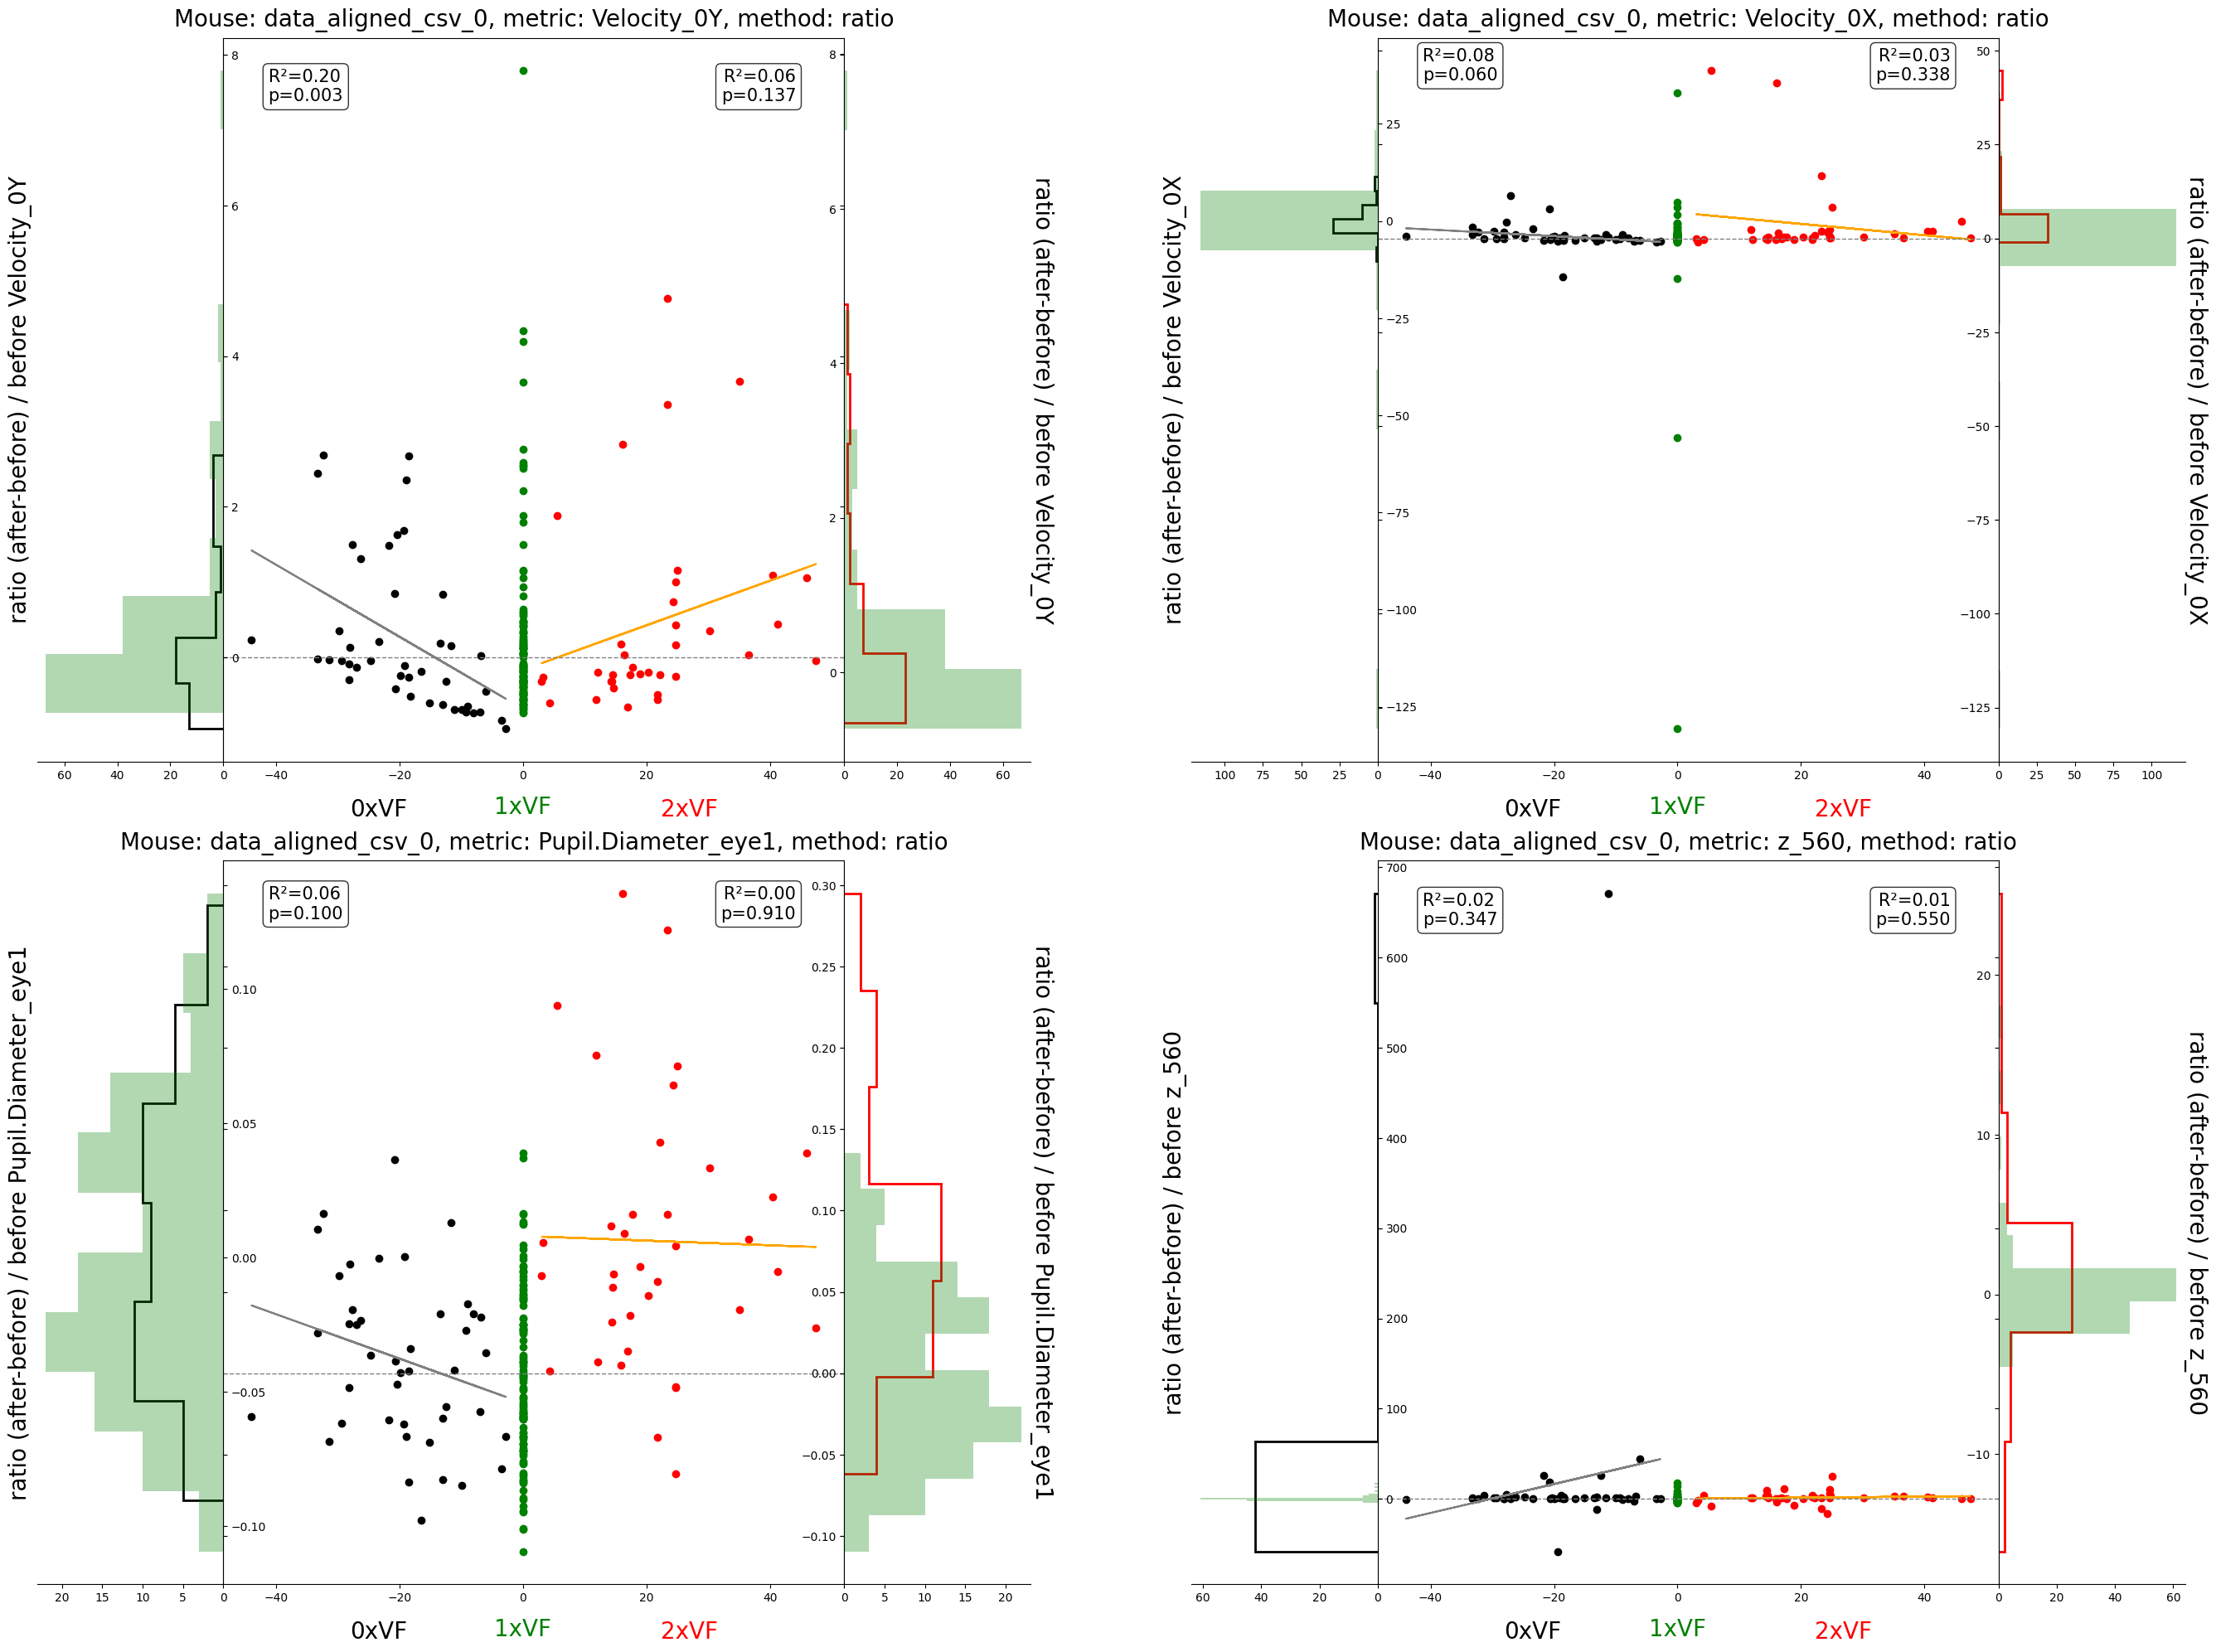

In [140]:
fig_1_grid(
    params_to_analyse=['Velocity_0Y', 'Velocity_0X', 'Pupil.Diameter_eye1', 'z_560'],
    mouse='data_aligned_csv_0',
    method='ratio'
)